---
title: "Edge detection with the Sobel operator"
author: "FR"
date: "2024-01-01"
categories: [general, eng, Python]
tags: [edge, detection, sobel, images, opencv]
format:
  html:
    code-fold: true
execute:
  echo: true
---

We have to detect if a pixel in an image is a border pixel or not. 
To do that, we use the [Sobel operator](https://en.wikipedia.org/wiki/Sobel_operator)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

def show_img(img, title='Image'):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

The example image I use is the dragon of Harry Potter

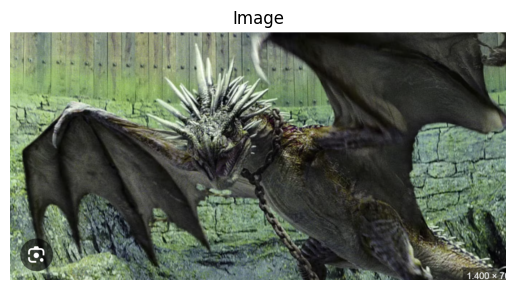

In [2]:
path = 'lo_spinato.png'
img = cv2.imread(path)
show_img(img)

Using the 2d convolution (function provided in scipy) I can make more white the border pixels, in a grayscale image.

Time: 0.1543 seconds


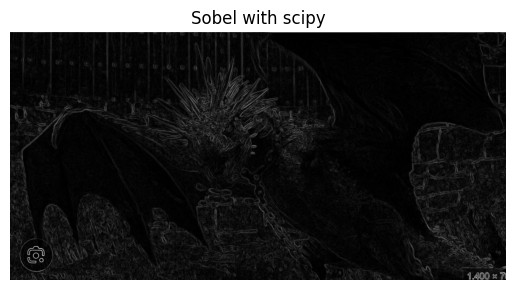

In [5]:
from scipy.signal import convolve2d


start = time.time()

sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

sobel_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1,-2,-1]
])

# Apply Sobel kernels to entire image at once
grad_x = convolve2d(img_gray, sobel_x, mode='valid')
grad_y = convolve2d(img_gray, sobel_y, mode='valid')

# Compute gradient magnitude
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Normalize
matrix0 = np.floor(255*(gradient_magnitude/np.max(gradient_magnitude))).astype(np.uint8)
#matrix0 = np.floor(np.exp(np.log(255) + np.log(gradient_magnitude) - np.log(np.max(gradient_magnitude)) ) ).astype(np.uint8)

print(f"Time: {time.time()-start:.4f} seconds")
show_img(matrix0, 'Sobel with scipy')

## Other methods You can try

If You need speed You should try to use the cv2 version of the code

In [4]:
sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

sobel_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1,-2,-1]
])

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

sobel_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1,-2,-1]
])

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


matrix = np.array(img_gray)

def gradient_pixel(x, y, img, x_kernel, y_kernel):
    
    region = img[(x-1):(x+2), (y-1):(y+2)]
    xgrad = np.sum(region*x_kernel)
    ygrad = np.sum(region*y_kernel)
    grad = np.sqrt(xgrad**2 + ygrad**2)

    return(grad)


nrow = matrix.shape[0]
ncol = matrix.shape[1]

matrix0 = matrix.copy()

for i in range(2, nrow-2):
    for j in range(2, ncol-2):
        matrix0[i,j] = gradient_pixel(i, j, matrix, sobel_x, sobel_y)


matrix0 = np.floor(255 * (matrix0 / np.max(matrix0)))

img_gray0 = matrix0.astype(np.uint8)

show_img(img_gray0)

In [ ]:
##make it faster with opencv
sobelxy = cv2.Sobel(src=img_gray, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=3) # Combined X and Y Sobel Edge Detection
img_sobelxy = sobelxy.astype(np.uint8)
show_img(img_sobelxy)

## using opencv (is faster)

In [ ]:
start = time.time()

# OpenCV implementation with proper normalization
sobel_x = cv2.Sobel(src=img_gray, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(src=img_gray, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=3)

# Compute gradient magnitude (like your implementation)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Normalize to 0-255 range (like your implementation)
sobel_normalized = np.uint8(255 * sobel_magnitude / np.max(sobel_magnitude))

print(time.time()-start)

show_img(sobel_normalized, 'OpenCV Sobel - Normalized')

In [ ]:
start = time.time()

# 1. Use CV_16S or CV_32F instead of CV_64F (faster, less precision)
sobel_x = cv2.Sobel(src=img_gray, ddepth=cv2.CV_16S, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(src=img_gray, ddepth=cv2.CV_16S, dx=0, dy=1, ksize=3)

# 2. Convert to absolute values (faster than squaring/sqrt)
abs_sobel_x = cv2.convertScaleAbs(sobel_x)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# 3. Approximate magnitude with weighted sum (much faster than sqrt)
sobel_magnitude = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

# 4. Normalize
sobel_normalized = np.uint8(3 * sobel_magnitude / np.max(sobel_magnitude))

print(f"Time: {time.time()-start:.4f} seconds")
show_img(sobel_normalized, 'Fast Sobel')

In [ ]:
start = time.time()

# Use CV_16S for faster computation
sobel_x = cv2.Sobel(src=img_gray, ddepth=cv2.CV_16S, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(src=img_gray, ddepth=cv2.CV_16S, dx=0, dy=1, ksize=3)

# Convert to absolute values
abs_sobel_x = cv2.convertScaleAbs(sobel_x)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# Approximate magnitude with weighted sum
sobel_magnitude = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

# Normalize with the multiplier you used before
sobel_normalized = np.uint8(255 * sobel_magnitude / np.max(sobel_magnitude))

print(f"Time: {time.time()-start:.4f} seconds")
show_img(sobel_normalized, 'Fast Sobel')

In [ ]:
start = time.time()

sobel_x = cv2.Sobel(src=img_gray, ddepth=cv2.CV_16S, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(src=img_gray, ddepth=cv2.CV_16S, dx=0, dy=1, ksize=3)

abs_sobel_x = cv2.convertScaleAbs(sobel_x)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# Use weight of 1.0 instead of 0.5 for brighter output
sobel_magnitude = cv2.addWeighted(abs_sobel_x, 1.0, abs_sobel_y, 1.0, 0)

# Normalize
sobel_normalized = np.uint8(255 * sobel_magnitude / np.max(sobel_magnitude))

print(f"Time: {time.time()-start:.4f} seconds")
show_img(sobel_normalized, 'Fast Sobel')

## using just numpy (is slower)

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view


start = time.time()
# Create sliding windows of 3x3 regions
windows = sliding_window_view(img_gray, (3, 3))

# Apply kernels to all windows at once
grad_x = np.sum(windows * sobel_x, axis=(-2, -1))
grad_y = np.sum(windows * sobel_y, axis=(-2, -1))

# Compute gradient magnitude
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Normalize
matrix0 = np.floor(255 * (gradient_magnitude / np.max(gradient_magnitude))).astype(np.uint8)

print(f"Time: {time.time()-start:.4f} seconds")
show_img(matrix0, 'Sobel with stride tricks')